# English Translation Intent Modeling для русскоязычных диалогов

**Цель ноутбука.** Построить отдельный (англоязычный) baseline иерархической
классификации интента диалога (`primaryintent`), используя **английские переводы**
исходных русскоязычных диалогов в колонке `dialogue_en`. Текущий ноутбук независим от
`04_baseline_modeling.ipynb` и `05_hierarchical_intent_modeling.ipynb`,
и предназначен для запуска в Google Colab.

**Важно про перевод.** Google Cloud Translation API — платный сервис, и для
воспроизводимости результатов мы НЕ требуем его наличия. Этот ноутбук по
умолчанию использует **бесплатную open-source модель перевода**
`Helsinki-NLP/opus-mt-ru-en` (Hugging Face Transformers), которая запускается
локально в Colab на GPU/CPU. Качество перевода может отличаться от Google
Translate (особенно на разговорной речи и сленге) — это ограничение нужно
явно упомянуть в отчёте.

**Чем этот ноутбук отличается от `05_hierarchical_intent_modeling.ipynb`.**

- Энкодер реплик — **англоязычный**: `bert-base-uncased`.
- Входной текст — **переводы** из `dialogue_en` (получены локально через
  open-source модель `Helsinki-NLP/opus-mt-ru-en`), а не оригинальный
  русский `dialogue`.
- Конфигурация по умолчанию ориентирована на **NVIDIA H100 80GB** (Colab Pro
  high RAM), но через флаги совместима с A100 / T4 / V100 / CPU.

**Краткий план:**

1. Установка зависимостей и импорты.
2. Подключение Google Drive, загрузка размеченного CSV, нормализация колонок.
3. **Подготовка переводов**: если в CSV ещё нет колонки `dialogue_en`
   (или часть переводов пустая), запускаем локальный перевод через
   `Helsinki-NLP/opus-mt-ru-en` и сохраняем рядом файл
   `dialogue_intent_annotation_1246_v1_annotated_with_en.csv`.
4. Стратифицированный split 70/15/15 для сценариев `full` и `clean`.
5. Утилиты оценки (`evaluate_predictions`, `plot_confusion_matrix`,
   `record_result`) с alias-обёртками без подчёркивания.
6. Аппаратная конфигурация (H100/A100/T4): bf16/fp16/fp32, batch size,
   gradient accumulation. FP8 — placeholder, в чистом PyTorch не активируется.
7. Архитектура: `dialogue_en` -> разбиение на utterances ->
   `bert-base-uncased` -> masked mean pooling -> bi-GRU -> dropout + linear
   на 15 классов.
8. Обучение собственным PyTorch-циклом (без HuggingFace `Trainer`) с
   взвешенной `CrossEntropyLoss`, mixed precision (`torch.amp.autocast`) и
   ранней остановкой по val macro-F1.
9. Сохранение артефактов под стабильными именами в `results/tables/` и
   `results/figures/` на Google Drive.

**Почему отдельный английский baseline.** Русскоязычные модели на маленьком
датасете (~1.2k диалогов) могут уступать сильным англоязычным энкодерам.
Перевод диалогов на английский + `bert-base-uncased` — стандартный способ
оценить, насколько английская предобученная семантика помогает на задаче
распознавания интента.

**Дисбаланс классов.** Класс `личное_общение` доминирует. В обучении
используется `CrossEntropyLoss(weight=...)` с весами, посчитанными только по
train-сплиту (как `class_weight='balanced'` в sklearn).

**Сценарии.** Эксперимент по умолчанию фокусируется на сценарии `clean`
(`isambiguous == 0`); сценарий переключается параметром `EN_SCENARIO`.


## 1. Установка зависимостей и импорты


In [1]:
# cell 1: installs
# В Colab обычно отсутствуют только transformers и зависимости MarianMT-перевода.
# torch, scikit-learn, pandas, numpy, matplotlib, seaborn, tqdm — как правило, есть.
# Раскомментируйте при первом запуске. sentencepiece + sacremoses нужны для
# Helsinki-NLP/opus-mt-ru-en (MarianTokenizer).
!pip install -q transformers sentencepiece sacremoses scikit-learn pandas numpy matplotlib seaborn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 25.3 MB/s eta 0:00:0000:01


In [2]:
# cell 2: imports
import os
import gc
import re
import json
import math
import glob
import random
import warnings
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import AutoTokenizer, AutoModel

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


## 2. Подключение Google Drive и пути к данным/результатам


In [3]:
# cell 3: drive mount and paths
# Пути к данным и результатам на Google Drive.
BASE_DIR = "/content/drive/MyDrive/russian-dialogue-intent-thesis"
BASEDIR = BASE_DIR  # alias без подчёркивания
DATA_DIR = f"{BASE_DIR}/data"
ANNO_DIR = f"{DATA_DIR}/annotation"
RESULTS_DIR = f"{BASE_DIR}/results"
RESULTSDIR = RESULTS_DIR
TABLES_DIR = f"{RESULTS_DIR}/tables"
TABLESDIR = TABLES_DIR
FIGURES_DIR = f"{RESULTS_DIR}/figures"
FIGURESDIR = FIGURES_DIR

# Канонический путь к размеченному CSV (русские диалоги + разметка интента).
ANNOTATED_CSV = f"{ANNO_DIR}/dialogue_intent_annotation_1246_v1_annotated.csv"

# Путь к CSV с добавленной колонкой dialogue_en (переводы). Если файл уже
# существует, он будет загружен и переводиться будут только пустые строки.
TRANSLATED_CSV = ANNOTATED_CSV.replace('.csv', '_with_en.csv')

# Open-source модель перевода RU -> EN (бесплатная, локальная).
MODEL_NAME_TRANSLATE = "Helsinki-NLP/opus-mt-ru-en"

# Управляющий флаг: запускать ли локальный перевод, если dialogue_en отсутствует
# или содержит пустые строки. True по умолчанию, т.к. английскому baseline
# колонка dialogue_en необходима.
RUN_TRANSLATION = True

# Монтирование Google Drive (если запущено в Colab).
try:
    from google.colab import drive  # type: ignore
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print("IN_COLAB:", IN_COLAB)
print("ANNOTATED_CSV:", ANNOTATED_CSV)
print("TRANSLATED_CSV:", TRANSLATED_CSV)

for d in (TABLES_DIR, FIGURES_DIR):
    try:
        os.makedirs(d, exist_ok=True)
    except Exception as exc:
        print(f"Не удалось создать {d}: {exc}")


Mounted at /content/drive
IN_COLAB: True
ANNOTATED_CSV: /content/drive/MyDrive/russian-dialogue-intent-thesis/data/annotation/dialogue_intent_annotation_1246_v1_annotated.csv
TRANSLATED_CSV: /content/drive/MyDrive/russian-dialogue-intent-thesis/data/annotation/dialogue_intent_annotation_1246_v1_annotated_with_en.csv


## 3. Загрузка размеченного CSV и нормализация колонок

CSV должен содержать колонки (после нормализации):
`dialogid`, `dialogue`, `primaryintent`, `isambiguous`.
Колонка `dialogue_en` опциональна на этом этапе — она будет создана
(или дополнена) в разделе подготовки переводов ниже, если её ещё нет.
Если в файле использованы имена с подчёркиваниями (`dialog_id`,
`primary_intent`, `is_ambiguous`) — они автоматически переименовываются.

Если уже существует файл `TRANSLATED_CSV` (с готовыми переводами в
`dialogue_en`), он будет предпочтён базовому `ANNOTATED_CSV`.
Если оба пути недоступны, выполняется рекурсивный поиск по `BASE_DIR`
любого CSV, чьё имя содержит `annotated` или `dialogue_intent_annotation`.


In [4]:
# cell 4: load csv
def _find_annotated_csv(base_dir, primary_path, translated_path=None):
    # 1) Если уже есть файл с переводами — используем его.
    if translated_path and os.path.exists(translated_path):
        return translated_path
    # 2) Канонический путь к размеченному CSV.
    if os.path.exists(primary_path):
        return primary_path
    # 3) Рекурсивный поиск.
    if not os.path.isdir(base_dir):
        return None
    patterns = [
        os.path.join(base_dir, "**", "*annotated*.csv"),
        os.path.join(base_dir, "**", "dialogue_intent_annotation*.csv"),
    ]
    candidates = []
    for pat in patterns:
        candidates.extend(glob.glob(pat, recursive=True))
    candidates = sorted(set(candidates))
    if not candidates:
        return None
    print(f"[load_csv] Используем найденный CSV вместо {primary_path}:")
    for c in candidates:
        print(f"  - {c}")
    en_pref = [c for c in candidates if re.search(r"[_-]en[_.-]|english|translated|with_en", c, re.I)]
    return (en_pref or candidates)[0]


if "df" not in globals():
    csv_path = _find_annotated_csv(BASE_DIR, ANNOTATED_CSV, TRANSLATED_CSV)
    if csv_path is None:
        raise FileNotFoundError(
            f"Не удалось найти размеченный CSV. Проверьте путь ANNOTATED_CSV: {ANNOTATED_CSV}"
        )
    df = pd.read_csv(csv_path)
    print(f"Loaded CSV: {csv_path}")
print("Размер df:", df.shape)
print("Колонки:", list(df.columns))


Loaded CSV: /content/drive/MyDrive/russian-dialogue-intent-thesis/data/annotation/dialogue_intent_annotation_1246_v1_annotated_with_en.csv
Размер df: (1246, 14)
Колонки: ['dialogid', 'split', 'dialogue', 'summary', 'n_utterances', 'dialogue_words', 'summary_words', 'primaryintent', 'secondary_intent', 'isambiguous', 'annotation_notes', 'annotator', 'label_version', 'dialogue_en']


In [5]:
# cell 5: normalize column names
# Нормализация имён колонок к формату без подчёркивания. Колонка `dialogue_en`
# на этом этапе не обязательна — если её нет, она будет создана в разделе
# подготовки переводов ниже.
RENAME_MAP = {
    "dialog_id": "dialogid",
    "primary_intent": "primaryintent",
    "is_ambiguous": "isambiguous",
}
for src, dst in RENAME_MAP.items():
    if src in df.columns and dst not in df.columns:
        df = df.rename(columns={src: dst})

REQUIRED_COLS = ["dialogid", "dialogue", "primaryintent", "isambiguous"]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(
        f"В df отсутствуют необходимые колонки: {missing}. Доступные: {list(df.columns)}"
    )

df["isambiguous"] = df["isambiguous"].fillna(0).astype(int)

# Если dialogue_en уже есть — приводим dtype к строке, чтобы избежать предупреждений
# pandas при последующей дозаписи переводов.
if "dialogue_en" in df.columns:
    df["dialogue_en"] = df["dialogue_en"].fillna("").astype(str)
    en_series = df["dialogue_en"].str.strip()
    n_empty_en = int((en_series == "").sum())
    n_total = len(df)
    print(
        f"dialogue_en присутствует. Не пуст: {int((en_series != '').sum())} / {n_total}"
        f" (пустых: {n_empty_en})."
    )
else:
    print("dialogue_en пока отсутствует — будет создана в разделе подготовки переводов.")

print("Колонки после нормализации:", list(df.columns))
print("Число классов primaryintent:", df["primaryintent"].nunique())
print(df[["dialogid", "primaryintent", "isambiguous"]].head())


dialogue_en присутствует. Не пуст: 0 / 1246 (пустых: 1246).
Колонки после нормализации: ['dialogid', 'split', 'dialogue', 'summary', 'n_utterances', 'dialogue_words', 'summary_words', 'primaryintent', 'secondary_intent', 'isambiguous', 'annotation_notes', 'annotator', 'label_version', 'dialogue_en']
Число классов primaryintent: 15
   dialogid               primaryintent  isambiguous
0   train_6           финансовый_вопрос            0
1   train_9  интервью_или_собеседование            0
2  train_18          бытовое_обсуждение            0
3  train_27  интервью_или_собеседование            0
4  train_35           обсуждение_досуга            0


## 3.5. Подготовка английских переводов (open-source Helsinki-NLP)

Google Cloud Translation API — платный сервис, поэтому здесь мы используем
бесплатную open-source модель `Helsinki-NLP/opus-mt-ru-en` (MarianMT, Hugging
Face Transformers). Модель скачивается локально в Colab и работает на GPU
(если доступен) или на CPU.

Логика этого раздела:

1. Если `RUN_TRANSLATION = False` — раздел полностью пропускается. Этот
   режим имеет смысл только если в CSV уже есть полная колонка `dialogue_en`.
2. Если уже существует файл `TRANSLATED_CSV` — он загружается, и переводятся
   только строки с пустым `dialogue_en` (докатываем чекпойнт).
3. Длинные диалоги предварительно нарезаются на utterances (по разделителям
   реплик / переводам строк / чанкам), переводятся батчами, и переводы
   склеиваются обратно через `\n`. Это нужно, чтобы избежать обрезания по
   `max_length` MarianMT (512 токенов).
4. Промежуточные результаты сохраняются на Google Drive каждые 25 строк,
   utf-8.

**Качество.** MarianMT даёт разумный перевод, но на разговорной речи /
сленге может уступать Google Translate. Это ограничение обязательно
упомянуть в отчёте.


In [6]:
# cell 5.1: translation imports and config
# Импорты для локального перевода через Helsinki-NLP/opus-mt-ru-en.
# Если transformers/sentencepiece/sacremoses не установлены — раскомментировать
# pip install выше и перезапустить runtime.
from transformers import MarianMTModel, MarianTokenizer

TRANSLATION_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRANSLATION_BATCH_SIZE = 16 if TRANSLATION_DEVICE.type == "cuda" else 4
TRANSLATION_MAX_LENGTH = 512        # лимит токенов MarianMT
TRANSLATION_CHUNK_CHARS = 800       # запас на случай очень длинных utterances
CHECKPOINT_EVERY = 25               # как часто сбрасывать TRANSLATED_CSV на диск

print("MODEL_NAME_TRANSLATE:", MODEL_NAME_TRANSLATE)
print("TRANSLATION_DEVICE:", TRANSLATION_DEVICE)
print("TRANSLATION_BATCH_SIZE:", TRANSLATION_BATCH_SIZE)
print("RUN_TRANSLATION:", RUN_TRANSLATION)


MODEL_NAME_TRANSLATE: Helsinki-NLP/opus-mt-ru-en
TRANSLATION_DEVICE: cuda
TRANSLATION_BATCH_SIZE: 16
RUN_TRANSLATION: True


In [7]:
# cell 5.2: chunking helpers for long dialogues
# Разбиение длинного русского диалога на куски, безопасные для перевода
# (по строкам / репликам / по длине символов). После перевода куски
# склеиваются обратно через \n.

_UTTERANCE_SPLIT_RE = re.compile(r"(?:\r?\n)+|(?<=[\.\!\?])\s+(?=[А-ЯA-Z])")


def _split_long_chunk(text: str, max_chars: int) -> list:
    """Жёстко режет строку на куски по max_chars символов, стараясь по пробелам."""
    text = text.strip()
    if len(text) <= max_chars:
        return [text]
    out, buf = [], []
    cur_len = 0
    for token in re.split(r"(\s+)", text):
        if cur_len + len(token) > max_chars and buf:
            out.append("".join(buf).strip())
            buf, cur_len = [], 0
        buf.append(token)
        cur_len += len(token)
    if buf:
        rest = "".join(buf).strip()
        if rest:
            out.append(rest)
    return [c for c in out if c]


def split_ru_dialogue_for_translation(text: str, max_chars: int = TRANSLATION_CHUNK_CHARS):
    """
    Возвращает (chunks, joiners), где joiners[i] — разделитель между chunks[i]
    и chunks[i+1] в исходном тексте (обычно '\n' для реплик).
    Для перевода важен порядок и склейка с переводами строк.
    """
    if text is None:
        return [], []
    text = str(text).strip()
    if not text:
        return [], []

    # Сначала пытаемся разделить по явным переводам строк (реплики диалога).
    if "\n" in text:
        parts = [p.strip() for p in text.splitlines()]
        parts = [p for p in parts if p]
    else:
        # Иначе режем по концам предложений.
        parts = [p.strip() for p in _UTTERANCE_SPLIT_RE.split(text) if p and p.strip()]
        if not parts:
            parts = [text]

    # Если какой-то кусок всё ещё слишком длинный — режем дальше.
    chunks = []
    for p in parts:
        if len(p) <= max_chars:
            chunks.append(p)
        else:
            chunks.extend(_split_long_chunk(p, max_chars))

    if not chunks:
        chunks = [text]

    # Разделитель — перевод строки между репликами.
    joiners = ["\n"] * max(0, len(chunks) - 1)
    return chunks, joiners


In [8]:
# cell 5.3: load translation model + translate_batch helper
_TRANSLATION_MODEL = None
_TRANSLATION_TOKENIZER = None


def _ensure_translation_model():
    """Лениво грузим MarianMT (Helsinki-NLP/opus-mt-ru-en) на GPU/CPU."""
    global _TRANSLATION_MODEL, _TRANSLATION_TOKENIZER
    if _TRANSLATION_MODEL is None or _TRANSLATION_TOKENIZER is None:
        print(f"Загружаем модель перевода {MODEL_NAME_TRANSLATE} на {TRANSLATION_DEVICE}...")
        _TRANSLATION_TOKENIZER = MarianTokenizer.from_pretrained(MODEL_NAME_TRANSLATE)
        _TRANSLATION_MODEL = MarianMTModel.from_pretrained(MODEL_NAME_TRANSLATE).to(TRANSLATION_DEVICE)
        _TRANSLATION_MODEL.eval()
    return _TRANSLATION_MODEL, _TRANSLATION_TOKENIZER


@torch.no_grad()
def translate_batch_ru_en(texts, batch_size: int = TRANSLATION_BATCH_SIZE):
    """
    Переводит список русских строк в английские. Не делает разбиения длинных
    диалогов — для этого используйте translate_long_ru_text ниже.
    """
    if not texts:
        return []
    model, tokenizer = _ensure_translation_model()
    out = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) if t is not None else "" for t in texts[i : i + batch_size]]
        # Пустые строки переводить не нужно.
        non_empty_idx = [j for j, t in enumerate(batch) if t.strip()]
        translated = [""] * len(batch)
        if non_empty_idx:
            sub = [batch[j] for j in non_empty_idx]
            enc = tokenizer(
                sub,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=TRANSLATION_MAX_LENGTH,
            ).to(TRANSLATION_DEVICE)
            gen = model.generate(
                **enc,
                max_length=TRANSLATION_MAX_LENGTH,
                num_beams=4,
                early_stopping=True,
            )
            decoded = tokenizer.batch_decode(gen, skip_special_tokens=True)
            for j, txt in zip(non_empty_idx, decoded):
                translated[j] = txt
        out.extend(translated)
    return out


def translate_long_ru_text(text: str) -> str:
    """Перевод одного длинного диалога: split -> translate -> rejoin по \n."""
    chunks, _joiners = split_ru_dialogue_for_translation(text)
    if not chunks:
        return ""
    translated = translate_batch_ru_en(chunks)
    # Склеиваем переведённые куски через перевод строки (как реплики диалога).
    return "\n".join(t.strip() for t in translated if t is not None)


In [9]:
# cell 5.4: smoke test + full translation pass
# Подготовка: если уже существует TRANSLATED_CSV — подтягиваем из него
# готовые переводы в текущий df (по dialogid).

def _ensure_dialogue_en_column(df):
    if "dialogue_en" not in df.columns:
        df["dialogue_en"] = ""
    df["dialogue_en"] = df["dialogue_en"].fillna("").astype(str)
    return df


df = _ensure_dialogue_en_column(df)

# Если на Drive уже есть чекпойнт переводов — подгружаем готовые dialogue_en.
if os.path.exists(TRANSLATED_CSV):
    try:
        df_prev = pd.read_csv(TRANSLATED_CSV)
        if "dialogue_en" in df_prev.columns and "dialogid" in df_prev.columns:
            df_prev["dialogue_en"] = df_prev["dialogue_en"].fillna("").astype(str)
            prev_map = dict(zip(df_prev["dialogid"], df_prev["dialogue_en"]))
            mask_empty = df["dialogue_en"].str.strip() == ""
            df.loc[mask_empty, "dialogue_en"] = df.loc[mask_empty, "dialogid"].map(prev_map).fillna("")
            df["dialogue_en"] = df["dialogue_en"].fillna("").astype(str)
            print(f"Подтянули переводы из чекпойнта {TRANSLATED_CSV} (строк: {len(df_prev)}).")
    except Exception as exc:
        print(f"Не удалось прочитать существующий TRANSLATED_CSV: {exc}")

n_total = len(df)
n_missing = int((df["dialogue_en"].str.strip() == "").sum())
print(f"Перед переводом: пустых dialogue_en = {n_missing} / {n_total}.")


def _save_translated(df, path):
    try:
        df.to_csv(path, index=False, encoding="utf-8")
    except Exception as exc:
        print(f"Не удалось сохранить {path}: {exc}")


if not RUN_TRANSLATION:
    print("RUN_TRANSLATION=False — этап локального перевода пропущен.")
elif n_missing == 0:
    print("Все строки уже переведены — этап локального перевода пропущен.")
else:
    # Smoke test: переводим первую непустую русскую строку без перевода.
    smoke_idx = df.index[df["dialogue_en"].str.strip() == ""].tolist()[:1]
    if smoke_idx:
        idx0 = smoke_idx[0]
        ru0 = str(df.at[idx0, "dialogue"])[:600]
        print("[smoke] RU:", ru0.replace("\n", " ⏎ ")[:200])
        en0 = translate_long_ru_text(ru0)
        print("[smoke] EN:", en0.replace("\n", " ⏎ ")[:200])

    # Полный проход по всем пустым dialogue_en.
    missing_idx = df.index[df["dialogue_en"].str.strip() == ""].tolist()
    print(f"Запускаем перевод {len(missing_idx)} диалогов через {MODEL_NAME_TRANSLATE}...")
    done_since_ckpt = 0
    for idx in tqdm(missing_idx, desc="translate ru->en"):
        ru_text = df.at[idx, "dialogue"]
        try:
            en_text = translate_long_ru_text(ru_text)
        except Exception as exc:
            print(f"[warn] перевод dialogid={df.at[idx, 'dialogid']} упал: {exc}")
            en_text = ""
        df.at[idx, "dialogue_en"] = en_text
        done_since_ckpt += 1
        if done_since_ckpt >= CHECKPOINT_EVERY:
            _save_translated(df, TRANSLATED_CSV)
            done_since_ckpt = 0

    # Финальный сохранитель чекпойнта.
    _save_translated(df, TRANSLATED_CSV)
    print(f"Готово. Файл с переводами: {TRANSLATED_CSV}")

# Защита от dtype-предупреждений pandas в дальнейших ячейках.
df["dialogue_en"] = df["dialogue_en"].fillna("").astype(str)

# Финальная валидация: для английского baseline dialogue_en обязателен.
en_series = df["dialogue_en"].str.strip()
n_empty_en = int((en_series == "").sum())
n_total = len(df)
print(f"После перевода: dialogue_en не пуст: {int((en_series != '').sum())} / {n_total}.")
if n_empty_en == n_total:
    raise ValueError(
        "Все значения 'dialogue_en' пустые после этапа перевода. "
        "Включите RUN_TRANSLATION=True или предоставьте CSV с готовыми "
        "английскими переводами в колонке 'dialogue_en'."
    )
if n_empty_en > 0.5 * n_total:
    raise ValueError(
        f"Более половины 'dialogue_en' пустые ({n_empty_en}/{n_total}). "
        "Перезапустите этап перевода (RUN_TRANSLATION=True) или проверьте, "
        "что модель Helsinki-NLP/opus-mt-ru-en доступна."
    )


Подтянули переводы из чекпойнта /content/drive/MyDrive/russian-dialogue-intent-thesis/data/annotation/dialogue_intent_annotation_1246_v1_annotated_with_en.csv (строк: 1246).
Перед переводом: пустых dialogue_en = 1246 / 1246.
[smoke] RU: #Person1#: Ну вот. ⏎ #Person2#: Спасибо. Сколько стоит проезд? ⏎ #Person1#: 10 долларов. ⏎ #Person2#: Как же так? ⏎ #Person1#: Ну, ставка два доллара за первые два километра и двадцать центов за кажды
Загружаем модель перевода Helsinki-NLP/opus-mt-ru-en на cuda...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

[smoke] EN: #Person1#: Here we go. ⏎ #Person2#:Thank you. How much is travel? ⏎ #Person1#: $10. ⏎ #Person2#: How so? ⏎ #Person1#: Well, two dollars for the first two kilometers and twenty cents for every next 200
Запускаем перевод 1246 диалогов через Helsinki-NLP/opus-mt-ru-en...


translate ru->en:   0%|          | 0/1246 [00:00<?, ?it/s]

Готово. Файл с переводами: /content/drive/MyDrive/russian-dialogue-intent-thesis/data/annotation/dialogue_intent_annotation_1246_v1_annotated_with_en.csv
После перевода: dialogue_en не пуст: 1246 / 1246.


## 4. Разбиение на выборки (train/val/test)

Стратифицированное разбиение по `primaryintent` в пропорции 70/15/15. Логика
устойчива к редким классам — классы с числом примеров `< min_per_class`
помещаются целиком в train. Логика совместима со сплитами в
`04_baseline_modeling.ipynb` и `05_hierarchical_intent_modeling.ipynb`,
поэтому индексы train/val/test сопоставимы.


In [10]:
# cell 6: make_splits
def make_splits(df, label_col, test_size=0.15, val_size=0.15, random_state=42, min_per_class=3):
    """Стратифицированный split с устойчивым поведением для редких классов."""
    df = df.reset_index(drop=True)
    counts = df[label_col].value_counts()
    rare_classes = counts[counts < min_per_class].index.tolist()
    if rare_classes:
        warnings.warn(
            f"Классы с числом примеров < {min_per_class} помещены целиком в train: "
            f"{rare_classes}",
            stacklevel=2,
        )

    rare_mask = df[label_col].isin(rare_classes)
    rare_idx = df.index[rare_mask].to_numpy()
    main_df = df.loc[~rare_mask]
    main_idx = main_df.index.to_numpy()
    y_main = main_df[label_col].to_numpy()

    sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trainval_pos, test_pos = next(sss_test.split(main_idx, y_main))
    test_idx = main_idx[test_pos]
    trainval_idx = main_idx[trainval_pos]
    y_trainval = y_main[trainval_pos]

    val_fraction = val_size / (1.0 - test_size)
    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=random_state)
    train_pos, val_pos = next(sss_val.split(trainval_idx, y_trainval))
    train_idx = trainval_idx[train_pos]
    val_idx = trainval_idx[val_pos]

    train_idx = np.concatenate([train_idx, rare_idx])
    rng = np.random.default_rng(random_state)
    rng.shuffle(train_idx)

    return {"train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx}


In [11]:
# cell 7: build df_full / df_clean and splits
df_full = df.reset_index(drop=True)
splits_full = make_splits(df_full, label_col="primaryintent", random_state=SEED)

df_clean = df[df["isambiguous"] == 0].reset_index(drop=True)
splits_clean = make_splits(df_clean, label_col="primaryintent", random_state=SEED)

# Aliases без подчёркивания (по требованию совместимости).
dffull = df_full
dfclean = df_clean
splitsfull = splits_full
splitsclean = splits_clean


def report_splits(name, df_scenario, splits):
    print(f"=== Сценарий: {name} ===  Размер: {len(df_scenario)}")
    for key in ("train_idx", "val_idx", "test_idx"):
        idx = splits[key]
        print(f"  {key}: {len(idx)}")
    print()

report_splits("full", df_full, splits_full)
report_splits("clean", df_clean, splits_clean)


=== Сценарий: full ===  Размер: 1246
  train_idx: 872
  val_idx: 187
  test_idx: 187

=== Сценарий: clean ===  Размер: 931
  train_idx: 651
  val_idx: 140
  test_idx: 140



## 5. Утилиты оценки и логирования

Функции `evaluate_predictions`, `plot_confusion_matrix`, `record_result`
поведенчески совместимы с baseline-ноутбуками. Также определены alias-имена
без подчёркивания (`evaluatepredictions`, `plotconfusionmatrix`,
`recordresult`).


In [12]:
# cell 8: evaluate_predictions / plot_confusion_matrix
def evaluate_predictions(y_true, y_pred, labels=None, target_names=None, title=None):
    """Считает accuracy, macro-F1, weighted-F1, classification_report и confusion_matrix."""
    if title:
        print(f"=== {title} ===")
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro-F1:    {macro_f1:.4f}")
    print(f"weighted-F1: {weighted_f1:.4f}")
    report = classification_report(
        y_true, y_pred, labels=labels, target_names=target_names, zero_division=0,
    )
    print(report)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": report,
        "confusion_matrix": cm,
        "labels": labels,
        "target_names": target_names,
    }


def plot_confusion_matrix(cm, labels, title=None, save_path=None, figsize=(10, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, ax=ax, cbar=False,
    )
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истинная метка")
    if title:
        ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        try:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            fig.savefig(save_path, dpi=120, bbox_inches="tight")
        except Exception as exc:
            print(f"Не удалось сохранить confusion matrix в {save_path}: {exc}")
    plt.show()
    return fig

evaluatepredictions = evaluate_predictions
plotconfusionmatrix = plot_confusion_matrix


In [13]:
# cell 9: record_result
results_rows = []

def record_result(model, scenario, split, metrics):
    results_rows.append({
        "model": model,
        "scenario": scenario,
        "split": split,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
    })

recordresult = record_result


## 6. Аппаратная конфигурация (H100 / A100 / T4)

Ноутбук рассчитан в первую очередь на **NVIDIA H100 80GB** (Colab Pro
high RAM), но универсален: при наличии менее мощного GPU (A100, T4, V100)
или CPU достаточно поставить `USE_H100_EXPERIMENTAL_CONFIG = False` и при
необходимости уменьшить `BATCH_SIZE`, `MAX_UTTERANCES`,
`MAX_UTTERANCE_LENGTH`.

**Mixed precision.** На H100/A100 рекомендуется `bf16` (большой динамический
диапазон, не требует `GradScaler`). На T4/V100 — `fp16` (требует
`GradScaler`). На CPU и при `USE_MIXED_PRECISION=False` используется fp32.

**FP8.** Полноценный FP8 в чистом PyTorch без NVIDIA Transformer Engine /
TensorRT-LLM активировать нельзя. Флаг `USE_FP8` сохранён как **placeholder**
для совместимости конфигурации; реализация остаётся на bf16/fp16/fp32.


In [14]:
# cell 10: hardware config and dtype/amp helpers

# === Главный аппаратный флаг ===
# H100 (Colab Pro / Pro+): True. На A100 — также True (bf16 поддерживается).
# На T4 / V100 / CPU — поставьте False, чтобы перейти в безопасный режим.
USE_H100_EXPERIMENTAL_CONFIG = True

# Mixed precision.
USE_MIXED_PRECISION = True
MIXED_PRECISION_DTYPE = "bf16"   # "bf16" | "fp16"

# FP8 — placeholder. В чистом PyTorch без NVIDIA Transformer Engine /
# TensorRT-LLM реальный FP8 не активируется: для tensor-core FP8 нужен
# transformer_engine.pytorch, который не входит в зависимости ноутбука.
# Если выставить USE_FP8 = True, ноутбук всё равно использует bf16/fp16 —
# флаг оставлен для документирования намерения и для будущей интеграции.
USE_FP8 = False

# Печать сведений о GPU и выбор device.
GPU_NAME = None
GPU_MEM_GB = None
if torch.cuda.is_available():
    GPU_NAME = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    GPU_MEM_GB = round(props.total_memory / (1024 ** 3), 1)
    print(f"GPU: {GPU_NAME}  ({GPU_MEM_GB} GB)  cuda_capability={props.major}.{props.minor}")
else:
    print("GPU не обнаружен — используется CPU. Рекомендуется GPU (T4/A100/H100).")

def _supports_bf16():
    if not torch.cuda.is_available():
        return False
    try:
        return torch.cuda.is_bf16_supported()
    except Exception:
        try:
            major = torch.cuda.get_device_properties(0).major
            return major >= 8
        except Exception:
            return False

REQUESTED_DTYPE = MIXED_PRECISION_DTYPE
EFFECTIVE_DTYPE = "fp32"
AMP_DTYPE = torch.float32

if not USE_MIXED_PRECISION or DEVICE.type != "cuda":
    EFFECTIVE_DTYPE = "fp32"
    AMP_DTYPE = torch.float32
elif MIXED_PRECISION_DTYPE == "bf16":
    if _supports_bf16():
        EFFECTIVE_DTYPE = "bf16"
        AMP_DTYPE = torch.bfloat16
    else:
        warnings.warn(
            "bf16 не поддерживается на текущем GPU; fallback в fp16.",
            stacklevel=2,
        )
        EFFECTIVE_DTYPE = "fp16"
        AMP_DTYPE = torch.float16
elif MIXED_PRECISION_DTYPE == "fp16":
    EFFECTIVE_DTYPE = "fp16"
    AMP_DTYPE = torch.float16
else:
    warnings.warn(
        f"Неизвестный MIXED_PRECISION_DTYPE={MIXED_PRECISION_DTYPE!r}; fallback в fp32.",
        stacklevel=2,
    )
    EFFECTIVE_DTYPE = "fp32"
    AMP_DTYPE = torch.float32

USE_AMP = EFFECTIVE_DTYPE in ("bf16", "fp16") and DEVICE.type == "cuda"
USE_GRAD_SCALER = EFFECTIVE_DTYPE == "fp16"

def _make_autocast_ctx():
    if not USE_AMP:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE)
    except Exception:
        try:
            return torch.cuda.amp.autocast(dtype=AMP_DTYPE)
        except Exception:
            return nullcontext()

def _make_grad_scaler():
    if not USE_GRAD_SCALER:
        return None
    try:
        return torch.amp.GradScaler("cuda")
    except Exception:
        try:
            return torch.cuda.amp.GradScaler()
        except Exception:
            return None

if USE_FP8:
    print(
        "[INFO] USE_FP8=True, но FP8 в чистом PyTorch без NVIDIA Transformer "
        "Engine / TensorRT-LLM не активируется. Используется bf16/fp16 как "
        "ближайший эквивалент."
    )

print({
    "GPU_NAME": GPU_NAME,
    "GPU_MEM_GB": GPU_MEM_GB,
    "USE_H100_EXPERIMENTAL_CONFIG": USE_H100_EXPERIMENTAL_CONFIG,
    "USE_MIXED_PRECISION": USE_MIXED_PRECISION,
    "REQUESTED_DTYPE": REQUESTED_DTYPE,
    "EFFECTIVE_DTYPE": EFFECTIVE_DTYPE,
    "USE_AMP": USE_AMP,
    "USE_GRAD_SCALER": USE_GRAD_SCALER,
    "USE_FP8": USE_FP8,
    "DEVICE": str(DEVICE),
})


GPU: NVIDIA A100-SXM4-80GB  (79.3 GB)  cuda_capability=8.0
{'GPU_NAME': 'NVIDIA A100-SXM4-80GB', 'GPU_MEM_GB': 79.3, 'USE_H100_EXPERIMENTAL_CONFIG': True, 'USE_MIXED_PRECISION': True, 'REQUESTED_DTYPE': 'bf16', 'EFFECTIVE_DTYPE': 'bf16', 'USE_AMP': True, 'USE_GRAD_SCALER': False, 'USE_FP8': False, 'DEVICE': 'cuda'}


## 7. Конфигурация модели и обучения

Параметры подобраны под H100 80GB. Для A100/T4/CPU поставьте
`USE_H100_EXPERIMENTAL_CONFIG = False` и (по необходимости) уменьшите
`BATCH_SIZE`, `MAX_UTTERANCES`, `MAX_UTTERANCE_LENGTH`.


In [15]:
# cell 11: english hierarchical model + training config

# === Энкодер реплик: английский ===
EN_MODEL_NAME = "bert-base-uncased"

# Сценарий: 'clean' (isambiguous == 0) или 'full'.
EN_SCENARIO = "clean"

# Геометрия диалога.
MAX_UTTERANCES = 32                # макс. число реплик на диалог
MAX_UTTERANCE_LENGTH = 64          # макс. токенов на реплику

# ===== safe / default режим (T4 / V100 / CPU) =====
BATCH_SIZE = 8
NUM_EPOCHS = 10
HIDDEN_SIZE = 128
DROPOUT = 0.3

FREEZE_TRANSFORMER = True
PARTIAL_UNFREEZE_LAST_N_LAYERS = 0

ENCODER_LR = 2e-5
HEAD_LR = 1e-3
WEIGHT_DECAY = 0.01

GRAD_ACCUM_STEPS = 1
PATIENCE = 3

SAVE_MODEL = False

# ===== H100 / Colab Pro экспериментальный режим (рекомендуется по умолчанию) =====
# 16 — безопасная стартовая точка для H100 80GB на bert-base-uncased и
# 32 utterances * 64 tokens. На H100 можно поднимать до 32; на A100 40GB —
# 8-16; на T4 — 4-8 (или FREEZE_TRANSFORMER=True).
if USE_H100_EXPERIMENTAL_CONFIG:
    FREEZE_TRANSFORMER = False
    PARTIAL_UNFREEZE_LAST_N_LAYERS = 4   # 2-4; для bert-base-uncased возьмём 4
    BATCH_SIZE = 16                       # 16-32 для H100 80GB
    NUM_EPOCHS = 10
    ENCODER_LR = 2e-5
    HEAD_LR = 1e-3
    GRAD_ACCUM_STEPS = 2                  # эффективный batch = 32
    WEIGHT_DECAY = 0.01
    PATIENCE = 3

# Aliases без подчёркивания (совместимость).
ENMODELNAME = EN_MODEL_NAME
ENSCENARIO = EN_SCENARIO

print({
    "EN_MODEL_NAME": EN_MODEL_NAME,
    "EN_SCENARIO": EN_SCENARIO,
    "MAX_UTTERANCES": MAX_UTTERANCES,
    "MAX_UTTERANCE_LENGTH": MAX_UTTERANCE_LENGTH,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "HIDDEN_SIZE": HIDDEN_SIZE,
    "DROPOUT": DROPOUT,
    "FREEZE_TRANSFORMER": FREEZE_TRANSFORMER,
    "PARTIAL_UNFREEZE_LAST_N_LAYERS": PARTIAL_UNFREEZE_LAST_N_LAYERS,
    "ENCODER_LR": ENCODER_LR,
    "HEAD_LR": HEAD_LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "GRAD_ACCUM_STEPS": GRAD_ACCUM_STEPS,
    "PATIENCE": PATIENCE,
    "SEED": SEED,
    "USE_H100_EXPERIMENTAL_CONFIG": USE_H100_EXPERIMENTAL_CONFIG,
    "EFFECTIVE_DTYPE": EFFECTIVE_DTYPE,
})


{'EN_MODEL_NAME': 'bert-base-uncased', 'EN_SCENARIO': 'clean', 'MAX_UTTERANCES': 32, 'MAX_UTTERANCE_LENGTH': 64, 'BATCH_SIZE': 16, 'NUM_EPOCHS': 10, 'HIDDEN_SIZE': 128, 'DROPOUT': 0.3, 'FREEZE_TRANSFORMER': False, 'PARTIAL_UNFREEZE_LAST_N_LAYERS': 4, 'ENCODER_LR': 2e-05, 'HEAD_LR': 0.001, 'WEIGHT_DECAY': 0.01, 'GRAD_ACCUM_STEPS': 2, 'PATIENCE': 3, 'SEED': 42, 'USE_H100_EXPERIMENTAL_CONFIG': True, 'EFFECTIVE_DTYPE': 'bf16'}


## 8. Разбиение английских диалогов на реплики (utterances)

Эвристика повторяет логику русского ноутбука, но дополнительно учитывает
особенности переводов Google Translate (часто сохраняет маркеры
`#Person1#:`, `#Person2#:` без изменений):

1. Маркеры спикеров `#Person1#:`, `#Speaker 1#:`, `#User#:`, `#Bot#:`,
   `#Agent#:`, `#Customer#:`, `#Operator#:`.
2. Если маркеров нет — разбиение по переводам строк.
3. Иначе — разбиение по `.!?`.

Пустые фрагменты отбрасываются, при отсутствии валидных реплик берётся
весь текст диалога как одна реплика.


In [16]:
# cell 12: split_dialogue_into_utterances
SPEAKER_TAG_RE_EN = re.compile(
    r"#\s*(?:Person|Speaker|User|Bot|Agent|Customer|Operator)\s*\d*\s*#\s*:",
    flags=re.IGNORECASE | re.UNICODE,
)
SENT_SPLIT_RE_EN = re.compile(r"(?<=[\.!?])\s+")


def _clean_uts(parts):
    out = []
    for p in parts:
        p = p.strip()
        if p:
            out.append(p)
    return out


def split_dialogue_into_utterances(text):
    """Разбивает английский (переведённый) текст диалога на список реплик."""
    if text is None:
        return []
    text = str(text).strip()
    if not text:
        return []

    if SPEAKER_TAG_RE_EN.search(text):
        parts = SPEAKER_TAG_RE_EN.split(text)
        uts = _clean_uts(parts)
        if uts:
            return uts

    if "\n" in text:
        uts = _clean_uts(text.split("\n"))
        if len(uts) > 1:
            return uts
        if uts:
            text = uts[0]

    uts = _clean_uts(SENT_SPLIT_RE_EN.split(text))
    if uts:
        return uts

    return [text]


In [17]:
# cell 13: sanity-check the splitter on a few dialogues_en
sample_df = df_clean.head(3) if len(df_clean) > 0 else df_full.head(3)
for _, row in sample_df.iterrows():
    en_text = row.get("dialogue_en", "")
    uts = split_dialogue_into_utterances(en_text)
    print(f"dialogid={row['dialogid']}  intent={row['primaryintent']}  n_utterances={len(uts)}")
    for i, u in enumerate(uts[:5]):
        preview = u[:160].replace("\n", " ")
        print(f"  [{i}] {preview}")
    print()


dialogid=train_6  intent=финансовый_вопрос  n_utterances=6
  [0] Here we go.
  [1] Thank you. How much is travel?
  [2] $10.
  [3] How so?
  [4] Well, two dollars for the first two kilometers and twenty cents for every next 200 meters.

dialogid=train_9  intent=интервью_или_собеседование  n_utterances=11
  [0] Excuse me, do you know where the visa department is?
  [1] Yes, I know. I'll take you there.
  [2] Thank you.
  [3] Do you apply for study or work abroad?
  [4] I want to study abroad.

dialogid=train_18  intent=бытовое_обсуждение  n_utterances=10
  [0] Wow, look at all these ice cream options!
  [1] Yes, there are many options. What's your favorite?
  [2] I love everything about chocolate most.
  [3] I love chocolate myself.
  [4] Is there any ice cream you don't like?



## 9. Подготовка данных под иерархическую модель


In [18]:
# cell 14: choose scenario and build label mapping
if EN_SCENARIO == "clean":
    df_scenario = df_clean
    splits_scenario = splits_clean
elif EN_SCENARIO == "full":
    df_scenario = df_full
    splits_scenario = splits_full
else:
    raise ValueError(f"Unknown EN_SCENARIO: {EN_SCENARIO}")

train_idx = splits_scenario["train_idx"]
val_idx = splits_scenario["val_idx"]
test_idx = splits_scenario["test_idx"]

labels_sorted = sorted(df_scenario["primaryintent"].unique().tolist())
label2id = {lab: i for i, lab in enumerate(labels_sorted)}
id2label = {i: lab for lab, i in label2id.items()}
NUM_CLASSES = len(labels_sorted)
print(f"Сценарий: {EN_SCENARIO}  classes: {NUM_CLASSES}")
print("labels:", labels_sorted)


Сценарий: clean  classes: 15
labels: ['бытовое_обсуждение', 'договоренность_или_планирование', 'жалоба_или_проблема', 'запрос_информации', 'интервью_или_собеседование', 'личное_общение', 'обсуждение_досуга', 'обсуждение_здоровья', 'обсуждение_путешествия', 'обсуждение_работы_или_учебы', 'покупка_или_заказ', 'просьба_о_помощи', 'сервисное_обращение', 'совет_или_рекомендация', 'финансовый_вопрос']


In [19]:
# cell 15: build python lists for examples (precompute utterances from dialogue_en)
def build_examples(df_scenario, idx_array):
    examples = []
    n_empty = 0
    for i in idx_array:
        row = df_scenario.iloc[int(i)]
        en_text = row.get("dialogue_en", "")
        if en_text is None or (isinstance(en_text, float) and math.isnan(en_text)):
            en_text = ""
        uts = split_dialogue_into_utterances(en_text)
        if not uts:
            uts = [str(en_text) if en_text is not None else ""]
            if not uts[0].strip():
                n_empty += 1
        examples.append({
            "dialogid": row["dialogid"],
            "utterances": uts[:MAX_UTTERANCES],
            "label": label2id[row["primaryintent"]],
            "isambiguous": int(row["isambiguous"]),
        })
    return examples, n_empty


train_examples, n_empty_train = build_examples(df_scenario, train_idx)
val_examples, n_empty_val = build_examples(df_scenario, val_idx)
test_examples, n_empty_test = build_examples(df_scenario, test_idx)

print(f"train={len(train_examples)}  val={len(val_examples)}  test={len(test_examples)}")
print(f"empty_dialogue_en: train={n_empty_train} val={n_empty_val} test={n_empty_test}")

if (n_empty_train + n_empty_val + n_empty_test) > 0.5 * (len(train_examples) + len(val_examples) + len(test_examples)):
    raise RuntimeError(
        "Более половины примеров не содержат английских переводов в "
        "'dialogue_en'. Проверьте, что CSV содержит реальные переводы "
        "(Google Translate)."
    )

print("Пример элемента train:", {
    "dialogid": train_examples[0]["dialogid"],
    "label": train_examples[0]["label"],
    "n_utterances": len(train_examples[0]["utterances"]),
    "first_utterance_preview": (train_examples[0]["utterances"][0][:160]
                                 if train_examples[0]["utterances"] else ""),
})


train=651  val=140  test=140
empty_dialogue_en: train=0 val=0 test=0
Пример элемента train: {'dialogid': 'train_5313', 'label': 0, 'n_utterances': 16, 'first_utterance_preview': "We're going to dinner tonight."}


## 10. Custom Dataset и collate_fn


In [20]:
# cell 16: tokenizer + Dataset
tokenizer = AutoTokenizer.from_pretrained(EN_MODEL_NAME)


class EnglishHierDialogueDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        return self.examples[idx]


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [21]:
# cell 17: collate_fn
def make_collate_fn(tokenizer, max_utterances=MAX_UTTERANCES, max_utt_len=MAX_UTTERANCE_LENGTH):
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

    def collate(batch):
        bsz = len(batch)
        utt_lists = [ex["utterances"][:max_utterances] for ex in batch]
        n_uts = [len(u) for u in utt_lists]
        max_n = max(n_uts) if n_uts else 1
        max_n = max(max_n, 1)

        flat_uts, owner = [], []
        for bi, uts in enumerate(utt_lists):
            for u in uts:
                flat_uts.append(u)
                owner.append(bi)

        if len(flat_uts) == 0:
            flat_uts = [""]
            owner = [0]

        enc = tokenizer(
            flat_uts,
            padding="max_length",
            truncation=True,
            max_length=max_utt_len,
            return_tensors="pt",
        )
        flat_input_ids = enc["input_ids"]
        flat_attn = enc["attention_mask"]
        L = flat_input_ids.size(1)

        input_ids = torch.full((bsz, max_n, L), pad_id, dtype=torch.long)
        attention_mask = torch.zeros((bsz, max_n, L), dtype=torch.long)
        utt_mask = torch.zeros((bsz, max_n), dtype=torch.float)

        counters = [0] * bsz
        for k, bi in enumerate(owner):
            ui = counters[bi]
            counters[bi] += 1
            input_ids[bi, ui] = flat_input_ids[k]
            attention_mask[bi, ui] = flat_attn[k]
            utt_mask[bi, ui] = 1.0

        labels = torch.tensor([ex["label"] for ex in batch], dtype=torch.long)
        dialogids = [ex["dialogid"] for ex in batch]
        isambiguous = torch.tensor([ex["isambiguous"] for ex in batch], dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "utt_mask": utt_mask,
            "labels": labels,
            "dialogids": dialogids,
            "isambiguous": isambiguous,
        }
    return collate


collate_fn = make_collate_fn(tokenizer)

train_ds = EnglishHierDialogueDataset(train_examples)
val_ds = EnglishHierDialogueDataset(val_examples)
test_ds = EnglishHierDialogueDataset(test_examples)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f"train_loader batches: {len(train_loader)}")


train_loader batches: 41


## 11. Архитектура: EnglishHierarchicalIntentClassifier

- **Utterance encoder**: `bert-base-uncased` (`AutoModel`). Заморожен при
  `FREEZE_TRANSFORMER=True`. При `PARTIAL_UNFREEZE_LAST_N_LAYERS > 0`
  размораживаются только последние N слоёв (по умолчанию 4 в H100-режиме).
  Pooling: masked mean pooling по токенам реплики (учитывает
  `attention_mask`).
- **Sequence encoder**: bi-directional `nn.GRU` над последовательностью
  utterance-эмбеддингов с учётом `utt_mask` через `pack_padded_sequence`.
- **Classifier**: dropout + `nn.Linear` -> `NUM_CLASSES` (15).


In [22]:
# cell 18: EnglishHierarchicalIntentClassifier
def masked_mean_pool(hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    s = (hidden.float() * mask).sum(dim=1)
    d = mask.sum(dim=1).clamp(min=1.0)
    return s / d


def _get_encoder_layers(encoder):
    inner = getattr(encoder, "encoder", None)
    if inner is None:
        return None
    layers = getattr(inner, "layer", None)
    if layers is None:
        return None
    try:
        _ = len(layers)
    except TypeError:
        return None
    return layers


class EnglishHierarchicalIntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes, hidden_size=128, dropout=0.3,
                 freeze_transformer=True, partial_unfreeze_last_n_layers=0):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.enc_hidden = self.encoder.config.hidden_size

        for p in self.encoder.parameters():
            p.requires_grad = False

        encoder_fully_trainable = False
        unfrozen_layer_indices = []

        if not freeze_transformer:
            layers = _get_encoder_layers(self.encoder)
            n = partial_unfreeze_last_n_layers
            if n is None or (isinstance(n, str) and n.lower() == "all"):
                for p in self.encoder.parameters():
                    p.requires_grad = True
                encoder_fully_trainable = True
                if layers is not None:
                    unfrozen_layer_indices = list(range(len(layers)))
            elif isinstance(n, int) and n > 0:
                if layers is None:
                    print(
                        "[warn] модель не предоставляет .encoder.layer — "
                        "PARTIAL_UNFREEZE_LAST_N_LAYERS игнорируется, "
                        "энкодер остаётся замороженным."
                    )
                else:
                    n_eff = min(n, len(layers))
                    unfrozen_layer_indices = list(range(len(layers) - n_eff, len(layers)))
                    for idx in unfrozen_layer_indices:
                        for p in layers[idx].parameters():
                            p.requires_grad = True

        self.encoder_fully_frozen = not any(
            p.requires_grad for p in self.encoder.parameters()
        )
        self.freeze_transformer = self.encoder_fully_frozen
        self._encoder_fully_trainable = encoder_fully_trainable
        self._unfrozen_layer_indices = unfrozen_layer_indices

        self.gru = nn.GRU(
            input_size=self.enc_hidden,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def encoder_trainable_parameters(self):
        return [p for p in self.encoder.parameters() if p.requires_grad]

    def head_parameters(self):
        params = []
        for module in (self.gru, self.classifier):
            params.extend(list(module.parameters()))
        return params

    def trainable_summary(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        enc_trainable = sum(p.numel() for p in self.encoder_trainable_parameters())
        head_trainable = sum(p.numel() for p in self.head_parameters() if p.requires_grad)
        return {
            "total_params": total,
            "trainable_params": trainable,
            "trainable_pct": 100.0 * trainable / max(total, 1),
            "encoder_trainable_params": enc_trainable,
            "head_trainable_params": head_trainable,
            "unfrozen_encoder_layers": list(self._unfrozen_layer_indices),
            "num_unfrozen_encoder_layers": len(self._unfrozen_layer_indices),
            "encoder_fully_frozen": self.encoder_fully_frozen,
            "encoder_fully_trainable": self._encoder_fully_trainable,
        }

    def encode_utterances(self, input_ids, attention_mask):
        B, U, L = input_ids.shape
        flat_ids = input_ids.view(B * U, L)
        flat_attn = attention_mask.view(B * U, L)
        if self.encoder_fully_frozen:
            with torch.no_grad():
                out = self.encoder(input_ids=flat_ids, attention_mask=flat_attn)
                hidden = out.last_hidden_state
        else:
            out = self.encoder(input_ids=flat_ids, attention_mask=flat_attn)
            hidden = out.last_hidden_state
        utt_emb = masked_mean_pool(hidden, flat_attn)
        return utt_emb.view(B, U, self.enc_hidden)

    def forward(self, input_ids, attention_mask, utt_mask):
        utt_emb = self.encode_utterances(input_ids, attention_mask)
        lengths = utt_mask.sum(dim=1).clamp(min=1).to(torch.long).cpu()
        # GRU выполняется в fp32 для стабильности при mixed precision.
        utt_emb_f32 = utt_emb.float()
        packed = nn.utils.rnn.pack_padded_sequence(
            utt_emb_f32, lengths=lengths, batch_first=True, enforce_sorted=False,
        )
        _, h_n = self.gru(packed)
        h_fwd = h_n[0]
        h_bwd = h_n[1]
        h = torch.cat([h_fwd, h_bwd], dim=-1)
        h = self.dropout(h)
        logits = self.classifier(h)
        return logits


## 12. Веса классов (по train-сплиту)


In [23]:
# cell 19: class weights
y_train = np.array([ex["label"] for ex in train_examples])
present_classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=present_classes, y=y_train)
class_weights = np.ones(NUM_CLASSES, dtype=np.float32)
for c, w in zip(present_classes, cw):
    class_weights[c] = w
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("class_weights:", dict(zip([id2label[i] for i in range(NUM_CLASSES)], class_weights.tolist())))


class_weights: {'бытовое_обсуждение': 1.142105221748352, 'договоренность_или_планирование': 2.7125000953674316, 'жалоба_или_проблема': 1.0850000381469727, 'запрос_информации': 1.6692308187484741, 'интервью_или_собеседование': 1.2400000095367432, 'личное_общение': 0.6200000047683716, 'обсуждение_досуга': 0.7749999761581421, 'обсуждение_здоровья': 1.9727272987365723, 'обсуждение_путешествия': 0.6382352709770203, 'обсуждение_работы_или_учебы': 0.5636363625526428, 'покупка_или_заказ': 0.8037037253379822, 'просьба_о_помощи': 1.6692308187484741, 'сервисное_обращение': 1.2764705419540405, 'совет_или_рекомендация': 0.6888889074325562, 'финансовый_вопрос': 1.6692308187484741}


## 13. Цикл обучения (чистый PyTorch, mixed precision)

Логируем `train_loss`, `val_loss`, `val_macro_f1` по эпохам. Mixed precision
включается через `torch.amp.autocast` с `dtype = bf16/fp16` в зависимости
от GPU. Для `fp16` дополнительно используется `GradScaler`; для `bf16` он
не нужен. Ранняя остановка по `val_macro_f1` с `PATIENCE` эпохами терпения.


In [24]:
# cell 20: model + optimizer + criterion + scaler
model = EnglishHierarchicalIntentClassifier(
    model_name=EN_MODEL_NAME,
    num_classes=NUM_CLASSES,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT,
    freeze_transformer=FREEZE_TRANSFORMER,
    partial_unfreeze_last_n_layers=PARTIAL_UNFREEZE_LAST_N_LAYERS,
).to(DEVICE)

_summary = model.trainable_summary()
print(
    f"total params:     {_summary['total_params']:,}\n"
    f"trainable params: {_summary['trainable_params']:,} "
    f"({_summary['trainable_pct']:.2f}%)\n"
    f"  - encoder trainable: {_summary['encoder_trainable_params']:,}\n"
    f"  - head    trainable: {_summary['head_trainable_params']:,}\n"
    f"unfrozen encoder layers: {_summary['num_unfrozen_encoder_layers']} "
    f"-> indices {_summary['unfrozen_encoder_layers']}\n"
    f"encoder_fully_frozen={_summary['encoder_fully_frozen']}  "
    f"encoder_fully_trainable={_summary['encoder_fully_trainable']}"
)

encoder_trainable = model.encoder_trainable_parameters()
head_trainable = [p for p in model.head_parameters() if p.requires_grad]

param_groups = []
if encoder_trainable:
    param_groups.append({
        "params": encoder_trainable,
        "lr": ENCODER_LR,
        "weight_decay": WEIGHT_DECAY,
        "name": "encoder",
    })
if head_trainable:
    param_groups.append({
        "params": head_trainable,
        "lr": HEAD_LR,
        "weight_decay": WEIGHT_DECAY,
        "name": "head",
    })

if not param_groups:
    raise RuntimeError(
        "Нет обучаемых параметров: проверьте FREEZE_TRANSFORMER и "
        "PARTIAL_UNFREEZE_LAST_N_LAYERS."
    )

optimizer = torch.optim.AdamW(param_groups)

for g in param_groups:
    n_params = sum(p.numel() for p in g["params"])
    print(
        f"optimizer group [{g['name']}]: lr={g['lr']}  "
        f"weight_decay={g['weight_decay']}  params={n_params:,}"
    )

criterion = nn.CrossEntropyLoss(weight=class_weights_t)

scaler = _make_grad_scaler()
print(f"USE_AMP={USE_AMP}  EFFECTIVE_DTYPE={EFFECTIVE_DTYPE}  USE_GRAD_SCALER={USE_GRAD_SCALER}  scaler={scaler is not None}")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


total params:     110,175,759
trainable params: 29,045,007 (26.36%)
  - encoder trainable: 28,351,488
  - head    trainable: 693,519
unfrozen encoder layers: 4 -> indices [8, 9, 10, 11]
encoder_fully_frozen=False  encoder_fully_trainable=False
optimizer group [encoder]: lr=2e-05  weight_decay=0.01  params=28,351,488
optimizer group [head]: lr=0.001  weight_decay=0.01  params=693,519
USE_AMP=True  EFFECTIVE_DTYPE=bf16  USE_GRAD_SCALER=False  scaler=False


In [25]:
# cell 21: evaluate / train helpers (with AMP)
@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, total_n = 0.0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        utt_mask = batch["utt_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        with _make_autocast_ctx():
            logits = model(input_ids, attention_mask, utt_mask)
        loss = criterion(logits.float(), labels)
        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_n += bs
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())
    if total_n == 0:
        return 0.0, 0.0, np.array([]), np.array([])
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    avg_loss = total_loss / total_n
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return avg_loss, macro_f1, y_true, y_pred


def train_one_epoch(model, loader, optimizer, criterion, scaler=None, grad_accum_steps=1):
    """Один проход по train-лоадеру с поддержкой gradient accumulation и AMP."""
    model.train()
    if model.freeze_transformer:
        model.encoder.eval()
    grad_accum_steps = max(int(grad_accum_steps), 1)

    total_loss, total_n = 0.0, 0
    optimizer.zero_grad()
    n_batches = len(loader)
    for step, batch in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        utt_mask = batch["utt_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        with _make_autocast_ctx():
            logits = model(input_ids, attention_mask, utt_mask)
        loss = criterion(logits.float(), labels)

        scaled_loss = loss / grad_accum_steps
        if scaler is not None:
            scaler.scale(scaled_loss).backward()
        else:
            scaled_loss.backward()

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_n += bs

        is_last = step == n_batches
        if step % grad_accum_steps == 0 or is_last:
            if scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 1.0,
                )
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 1.0,
                )
                optimizer.step()
            optimizer.zero_grad()

    return total_loss / max(total_n, 1)


In [26]:
# cell 22: main training loop with early stopping
history_rows = []
best_macro_f1 = -1.0
best_state = None
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion,
        scaler=scaler, grad_accum_steps=GRAD_ACCUM_STEPS,
    )
    val_loss, val_macro_f1, _, _ = evaluate_loader(model, val_loader, criterion)
    history_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_macro_f1": val_macro_f1,
    })
    print(f"epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_macro_f1={val_macro_f1:.4f}")

    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}  (best val macro-F1 = {best_macro_f1:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"Best val macro-F1 = {best_macro_f1:.4f}")


train:   0%|          | 0/41 [00:00<?, ?it/s]

epoch 01  train_loss=2.7317  val_loss=2.6062  val_macro_f1=0.0583


train:   0%|          | 0/41 [00:00<?, ?it/s]

epoch 02  train_loss=2.3375  val_loss=2.2805  val_macro_f1=0.2658


train:   0%|          | 0/41 [00:00<?, ?it/s]

...

epoch 08  train_loss=0.3303  val_loss=2.0688  val_macro_f1=0.3953


train:   0%|          | 0/41 [00:00<?, ?it/s]

epoch 09  train_loss=0.1859  val_loss=2.3508  val_macro_f1=0.3713


train:   0%|          | 0/41 [00:00<?, ?it/s]

epoch 10  train_loss=0.1044  val_loss=2.3024  val_macro_f1=0.4042
Early stopping at epoch 10  (best val macro-F1 = 0.4106)
Best val macro-F1 = 0.4106


Saved training history -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/english_hier_bigru_clean_training_history.csv
Saved training history figure -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/english_hier_bigru_clean_training_history.png


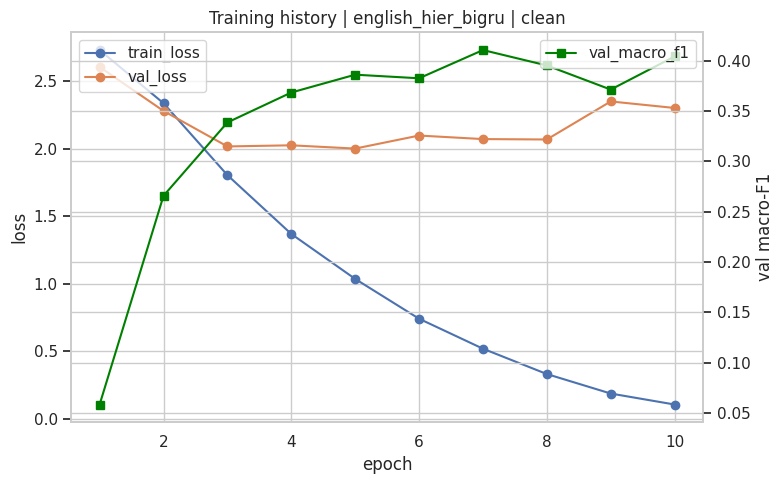

In [27]:
# cell 23: save training history (csv + figure)
history_df = pd.DataFrame(history_rows)
scenario_tag = EN_SCENARIO
model_tag = "english_hier_bigru"

os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

history_csv_path = f"{TABLES_DIR}/{model_tag}_{scenario_tag}_training_history.csv"
try:
    history_df.to_csv(history_csv_path, index=False, encoding="utf-8")
    print(f"Saved training history -> {history_csv_path}")
except Exception as exc:
    print(f"Не удалось сохранить {history_csv_path}: {exc}")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history_df["epoch"], history_df["train_loss"], label="train_loss", marker="o")
ax1.plot(history_df["epoch"], history_df["val_loss"], label="val_loss", marker="o")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["val_macro_f1"], color="green",
         label="val_macro_f1", marker="s")
ax2.set_ylabel("val macro-F1")
ax2.legend(loc="upper right")
plt.title(f"Training history | {model_tag} | {scenario_tag}")
plt.tight_layout()
history_png_path = f"{FIGURES_DIR}/{model_tag}_{scenario_tag}_training_history.png"
try:
    fig.savefig(history_png_path, dpi=120, bbox_inches="tight")
    print(f"Saved training history figure -> {history_png_path}")
except Exception as exc:
    print(f"Не удалось сохранить {history_png_path}: {exc}")
plt.show()

if SAVE_MODEL:
    models_dir = f"{BASE_DIR}/models"
    try:
        os.makedirs(models_dir, exist_ok=True)
        state_path = f"{models_dir}/{model_tag}_{scenario_tag}_best.pt"
        torch.save(best_state, state_path)
        print(f"Saved best model -> {state_path}")
    except Exception as exc:
        print(f"Не удалось сохранить модель: {exc}")


## 14. Оценка на val и test и сохранение артефактов


FINAL VAL  loss=2.0718  macro_f1=0.4106
=== english_hier_bigru | clean | val ===
accuracy:    0.4286
macro-F1:    0.4106
weighted-F1: 0.4316
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.67      0.50      0.57         8
договоренность_или_планирование       0.17      0.33      0.22         3
            жалоба_или_проблема       0.57      0.44      0.50         9
              запрос_информации       0.11      0.17      0.13         6
     интервью_или_собеседование       0.30      0.38      0.33         8
                 личное_общение       0.55      0.73      0.63        15
              обсуждение_досуга       0.70      0.58      0.64        12
            обсуждение_здоровья       0.40      0.40      0.40         5
         обсуждение_путешествия       0.50      0.47      0.48        15
    обсуждение_работы_или_учебы       0.46      0.35      0.40        17
              покупка_или_заказ       0.43      0.25   

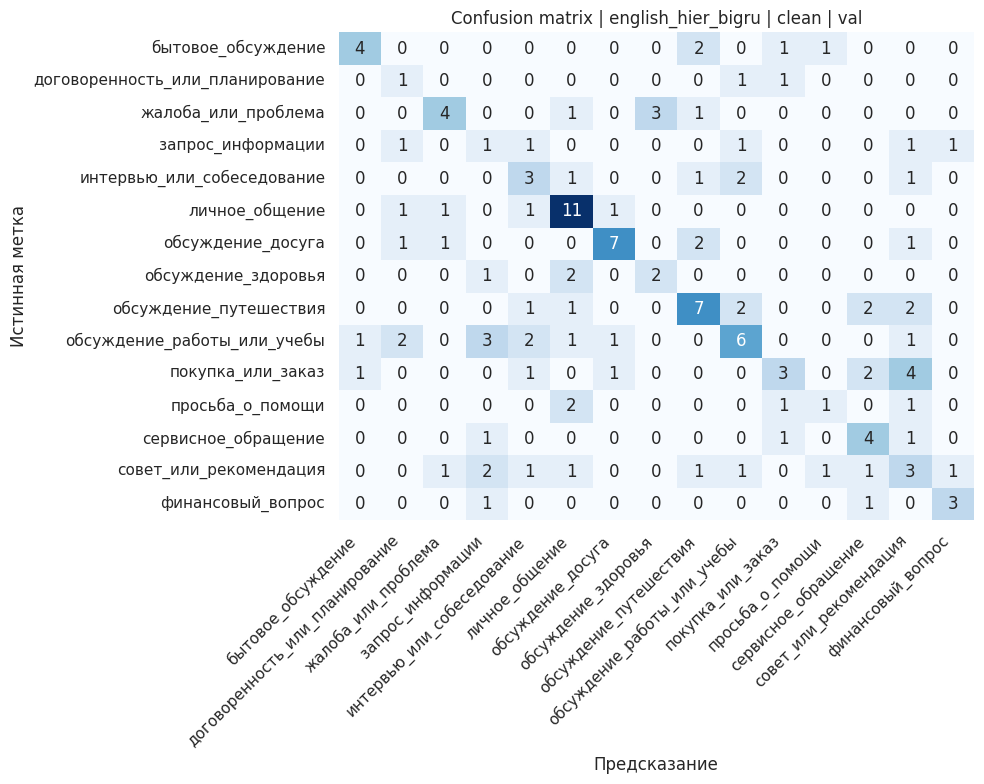

In [28]:
# cell 24: validation evaluation
val_loss, val_macro_f1, y_val_true, y_val_pred = evaluate_loader(model, val_loader, criterion)
print(f"FINAL VAL  loss={val_loss:.4f}  macro_f1={val_macro_f1:.4f}")
labels_for_report = list(range(NUM_CLASSES))
label_names = [id2label[i] for i in labels_for_report]
val_metrics = evaluate_predictions(
    y_val_true, y_val_pred,
    labels=labels_for_report,
    target_names=label_names,
    title=f"{model_tag} | {scenario_tag} | val",
)
plot_confusion_matrix(
    val_metrics["confusion_matrix"], label_names,
    title=f"Confusion matrix | {model_tag} | {scenario_tag} | val",
)
record_result(model_tag, scenario_tag, "val", val_metrics)


FINAL TEST  loss=1.9081  macro_f1=0.4089
=== english_hier_bigru | clean | test ===
accuracy:    0.4214
macro-F1:    0.4089
weighted-F1: 0.4190
                                 precision    recall  f1-score   support

             бытовое_обсуждение       0.50      0.50      0.50         8
договоренность_или_планирование       0.00      0.00      0.00         3
            жалоба_или_проблема       0.31      0.44      0.36         9
              запрос_информации       0.29      0.33      0.31         6
     интервью_или_собеседование       0.50      0.57      0.53         7
                 личное_общение       0.31      0.27      0.29        15
              обсуждение_досуга       0.55      0.50      0.52        12
            обсуждение_здоровья       0.83      1.00      0.91         5
         обсуждение_путешествия       0.45      0.60      0.51        15
    обсуждение_работы_или_учебы       0.78      0.41      0.54        17
              покупка_или_заказ       0.50      0.58 

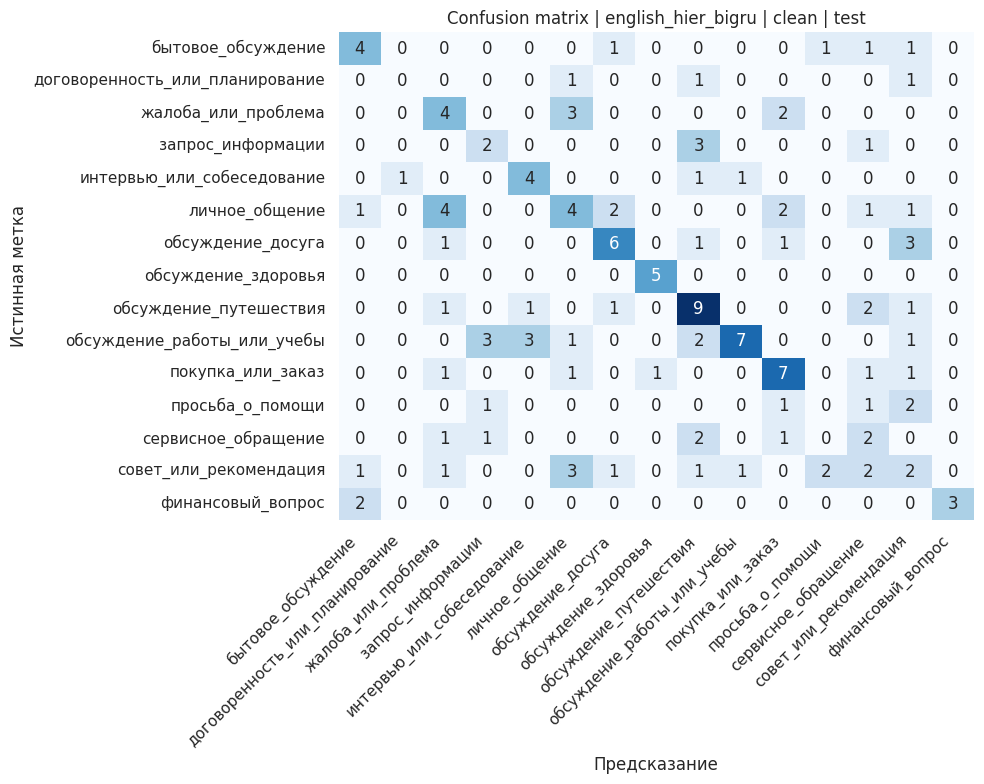

In [29]:
# cell 25: test evaluation
test_loss, test_macro_f1, y_test_true, y_test_pred = evaluate_loader(model, test_loader, criterion)
print(f"FINAL TEST  loss={test_loss:.4f}  macro_f1={test_macro_f1:.4f}")
test_metrics = evaluate_predictions(
    y_test_true, y_test_pred,
    labels=labels_for_report,
    target_names=label_names,
    title=f"{model_tag} | {scenario_tag} | test",
)
plot_confusion_matrix(
    test_metrics["confusion_matrix"], label_names,
    title=f"Confusion matrix | {model_tag} | {scenario_tag} | test",
)
record_result(model_tag, scenario_tag, "test", test_metrics)


In [30]:
# cell 26: save artifacts under stable names
def save_english_artifacts(model_tag, scenario, split, metrics, y_true, y_pred, label_names,
                           tables_dir=None, figures_dir=None):
    tables_dir = tables_dir or TABLES_DIR
    figures_dir = figures_dir or FIGURES_DIR
    os.makedirs(tables_dir, exist_ok=True)
    os.makedirs(figures_dir, exist_ok=True)

    report_dict = classification_report(
        y_true, y_pred, labels=list(range(len(label_names))),
        target_names=label_names, output_dict=True, zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_path = f"{tables_dir}/{model_tag}_{scenario}_classification_report_{split}.csv"
    report_df.to_csv(report_path, index=True, encoding="utf-8")

    cm = metrics.get("confusion_matrix")
    if cm is None:
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax, cbar=False)
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истинная метка")
    ax.set_title(f"Confusion matrix | {model_tag} | {scenario} | {split}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    cm_path = f"{figures_dir}/{model_tag}_{scenario}_confusion_matrix_{split}.png"
    fig.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"[save_english_artifacts] {split}: {report_path}, {cm_path}")
    return {"report": report_path, "confusion_matrix": cm_path}


save_english_artifacts(model_tag, scenario_tag, "val", val_metrics, y_val_true, y_val_pred, label_names)
save_english_artifacts(model_tag, scenario_tag, "test", test_metrics, y_test_true, y_test_pred, label_names)


[save_english_artifacts] val: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/english_hier_bigru_clean_classification_report_val.csv, /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/english_hier_bigru_clean_confusion_matrix_val.png
[save_english_artifacts] test: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/english_hier_bigru_clean_classification_report_test.csv, /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/english_hier_bigru_clean_confusion_matrix_test.png


{'report': '/content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/english_hier_bigru_clean_classification_report_test.csv',
 'confusion_matrix': '/content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/english_hier_bigru_clean_confusion_matrix_test.png'}

In [31]:
# cell 27: per-scenario metrics csv and test predictions csv
metrics_rows = [r for r in results_rows if r["model"] == model_tag and r["scenario"] == scenario_tag]
metrics_df = pd.DataFrame(metrics_rows, columns=["model", "scenario", "split", "accuracy", "macro_f1", "weighted_f1"])
metrics_path = f"{TABLES_DIR}/{model_tag}_{scenario_tag}_metrics.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")
print(f"Saved metrics -> {metrics_path}")

test_dialogids = [ex["dialogid"] for ex in test_examples]
test_isambig = [ex["isambiguous"] for ex in test_examples]
pred_df = pd.DataFrame({
    "dialogid": test_dialogids,
    "true_label": [id2label[int(y)] for y in y_test_true],
    "pred_label": [id2label[int(y)] for y in y_test_pred],
    "isambiguous": test_isambig,
})
pred_path = f"{TABLES_DIR}/{model_tag}_{scenario_tag}_test_predictions.csv"
pred_df.to_csv(pred_path, index=False, encoding="utf-8")
print(f"Saved test predictions -> {pred_path}")


Saved metrics -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/english_hier_bigru_clean_metrics.csv
Saved test predictions -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/english_hier_bigru_clean_test_predictions.csv


In [32]:
# cell 28: aggregate english_translation_metrics.csv across runs
agg_path = f"{TABLES_DIR}/english_translation_metrics.csv"
new_rows = pd.DataFrame(metrics_rows, columns=["model", "scenario", "split", "accuracy", "macro_f1", "weighted_f1"])
try:
    if os.path.exists(agg_path):
        prev = pd.read_csv(agg_path)
        merged = pd.concat([prev, new_rows], ignore_index=True)
        merged = merged.drop_duplicates(subset=["model", "scenario", "split"], keep="last")
    else:
        merged = new_rows
    merged = merged.sort_values(["model", "scenario", "split"]).reset_index(drop=True)
    merged.to_csv(agg_path, index=False, encoding="utf-8")
    print(f"Saved aggregated metrics -> {agg_path}")
    print(merged)
except Exception as exc:
    print(f"Не удалось обновить {agg_path}: {exc}")


Saved aggregated metrics -> /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/english_translation_metrics.csv
                model scenario split  accuracy  macro_f1  weighted_f1
0  english_hier_bigru    clean  test  0.421429  0.408852     0.418954
1  english_hier_bigru    clean   val  0.428571  0.410578     0.431646


## 15. Выводы по эксперименту с англоязычной моделью на переводах

В этом ноутбуке был проведён отдельный эксперимент по классификации интентов диалогов на основе англоязычных переводов `dialogue_en`. В качестве сценария использовался `clean`-поднабор, то есть только диалоги без признака неоднозначности `is_ambiguous == 1`. Размеры разбиения составили: train - 651 пример, validation - 140 примеров, test - 140 примеров. В данных не осталось пустых значений `dialogue_en`, поэтому все объекты из выбранного сценария были пригодны для обучения и оценки.

Для классификации использовалась иерархическая модель: англоязычный `bert-base-uncased` кодировал отдельные реплики, затем последовательность реплик обрабатывалась BiGRU, после чего применялся классификатор на 15 классов `primary_intent`. Эксперимент выполнялся с mixed precision в формате BF16, частичным размораживанием последних 4 слоёв BERT и разными learning rate для encoder и верхней классификационной части модели. Фактически в данном запуске использовалась GPU NVIDIA A100-SXM4-80GB, хотя конфигурация ноутбука также рассчитана на H100.

На validation модель достигла `accuracy = 0.4286`, `macro-F1 = 0.4106`, `weighted-F1 = 0.4316`. На test качество оказалось близким: `accuracy = 0.4214`, `macro-F1 = 0.4089`, `weighted-F1 = 0.4190`. Близость validation и test метрик показывает, что итоговая оценка достаточно стабильна для выбранного разбиения. При этом динамика обучения показывает признаки переобучения: train loss продолжал быстро снижаться, тогда как validation loss после нескольких эпох перестал заметно улучшаться, а validation macro-F1 колебался около 0.38-0.41.

По сравнению с предыдущими baseline-экспериментами результат англоязычной иерархической модели находится примерно на уровне лучшего русскоязычного transformer baseline на clean-сценарии. Test macro-F1 для англоязычной модели составил около `0.409`, что близко к результату русскоязычного transformer baseline на clean-поднаборе и выше, чем у TF-IDF + Logistic Regression и замороженной русскоязычной иерархической модели. Следовательно, перевод диалогов на английский и использование англоязычного BERT не даёт явного преимущества над сильным русскоязычным transformer baseline, но показывает сопоставимое качество.

Анализ per-class метрик показывает, что модель лучше справляется с некоторыми более выраженными и тематически устойчивыми классами. На test особенно высокое качество наблюдается для классов `обсуждение_здоровья` (`F1 = 0.91`) и `финансовый_вопрос` (`F1 = 0.75`). Умеренные результаты получены для классов `покупка_или_заказ`, `обсуждение_работы_или_учебы`, `интервью_или_собеседование`, `обсуждение_досуга` и `обсуждение_путешествия`. При этом редкие или семантически пересекающиеся классы остаются проблемными: `договоренность_или_планирование` и `просьба_о_помощи` получили `F1 = 0.00`, а `совет_или_рекомендация` и `сервисное_обращение` также имеют низкие значения F1.

Основная проблема эксперимента остаётся связанной с дисбалансом классов и близостью некоторых интентов по смыслу. Accuracy и weighted-F1 выглядят умеренно стабильными, но macro-F1 остаётся более важной метрикой, так как она сильнее отражает качество на редких классах. Низкие значения F1 для отдельных интентов показывают, что модель склонна лучше распознавать частые и тематически явные категории, но хуже работает с малочисленными и неоднозначными классами.

Итоговый вывод: англоязычный подход через машинный перевод и `bert-base-uncased` является рабочим baseline и показывает конкурентное качество на clean-поднаборе, но не демонстрирует убедительного улучшения по сравнению с русскоязычным transformer baseline. Для дальнейшей работы целесообразно сфокусироваться на улучшении разметки и состава редких классов, анализе confusion matrix, объединении или уточнении пересекающихся интентов, а также на дополнительных экспериментах с более сильными русскоязычными моделями и class weights / oversampling для редких категорий.